#Deepfake detection with MesoNet and a deep kernel Gaussian process

This notebook builds a facial forgery detector using MesoNet, the compact convolutional network from Afchar, Nozick, Yamagishi, and Echizen,
MesoNet: a Compact Facial Video Forgery Detection Network, IEEE WIFS 2018,
paired with a variational Gaussian process head following the deep kernel
learning approach of Wilson, Hu, Salakhutdinov, and Xing,
Stochastic Variational Deep Kernel Learning, NeurIPS 2016.

MesoNet targets an intermediate, mesoscopic level of image structure using
a shallow stack of four convolutional blocks. It has roughly 28,000
trainable parameters and trains from scratch, no pretrained weights are
required anywhere in this pipeline.

The Gaussian process head gives a calibrated variance alongside every
classification, which lets the system route uncertain images to a human
review queue instead of forcing a confident-looking answer on cases the
model is not actually sure about.

In [1]:
!pip install gpytorch torchvision torch --quiet
!pip install kaggle --quiet
!pip install matplotlib seaborn scikit-learn --quiet


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 291.2/291.2 kB 21.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 174.8/174.8 kB 19.8 MB/s eta 0:00:00


The dataset is 140k real and fake faces from Kaggle, published by user xhlulu.

How to get your kaggle.json:
1. Go to kaggle.com, then Account, then API, then Create New Token.
2. Upload the downloaded kaggle.json file when prompted by the cell below.

In [2]:
from google.colab import files
import os

uploaded = files.upload()

os.makedirs(os.path.expanduser('~/.kaggle'), exist_ok=True)

if uploaded:
    uploaded_filename = list(uploaded.keys())[0]
    with open(os.path.expanduser('~/.kaggle/kaggle.json'), 'wb') as f:
        f.write(uploaded[uploaded_filename])

os.chmod(os.path.expanduser('~/.kaggle/kaggle.json'), 0o600)
print('Kaggle credentials configured successfully.')

Saving kaggle.json to kaggle.json
Kaggle credentials configured successfully.


In [3]:
!kaggle datasets download -d xhlulu/140k-real-and-fake-faces
!unzip -q 140k-real-and-fake-faces.zip -d ./data
!find ./data -maxdepth 3 -type d

Dataset URL: https://www.kaggle.com/datasets/xhlulu/140k-real-and-fake-faces
License(s): other
100% 3.75G/3.75G [03:09<00:00, 21.2MB/s]

./data
./data/real_vs_fake
./data/real_vs_fake/real-vs-fake
./data/real_vs_fake/real-vs-fake/test
./data/real_vs_fake/real-vs-fake/valid
./data/real_vs_fake/real-vs-fake/train


Confirm the exact training directory from the listing above before
continuing. If it does not match ./data/real_vs_fake/real-vs-fake/train,
update DATA_DIR in block 4 to match what you actually see.

In [4]:
import torch
import torch.nn as nn
import gpytorch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import sqlite3
import os
import pandas as pd
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
if device.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

Using device: cuda
GPU: Tesla T4
VRAM: 15.6 GB


MesoNet works on faces resized to a fixed square input. We use 128 by 128
here, a common compromise between fidelity and speed. Normalization uses
the ImageNet mean and standard deviation purely as a conventional fixed
rescaling.

We take 8,000 images for training, balanced, 2,000 for testing, balanced,
and a separate 1,000 image validation split used only to calibrate the
uncertainty threshold later.

In [5]:
import random
DATA_DIR = './data/real_vs_fake/real-vs-fake/train'
TRAIN_SIZE = 8000
TEST_SIZE = 2000
VAL_SIZE = 1000
BATCH_SIZE = 32
IMG_SIZE = 128

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

full_dataset_train = datasets.ImageFolder(DATA_DIR, transform=train_transform)
full_dataset_eval = datasets.ImageFolder(DATA_DIR, transform=eval_transform)

targets = np.array(full_dataset_train.targets)
class_0_idx = np.where(targets == 0)[0]
class_1_idx = np.where(targets == 1)[0]

# Seed every generator used in this notebook.
# np.random.seed fixes the three class balanced splits below.
# torch.manual_seed fixes the Meso-4 weight initialisation and the
# training DataLoader shuffle order, which were previously unseeded.
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
train_idx = np.concatenate([
    np.random.choice(class_0_idx, TRAIN_SIZE // 2, replace=False),
    np.random.choice(class_1_idx, TRAIN_SIZE // 2, replace=False)
])

remaining_0 = np.setdiff1d(class_0_idx, train_idx)
remaining_1 = np.setdiff1d(class_1_idx, train_idx)

val_idx = np.concatenate([
    np.random.choice(remaining_0, VAL_SIZE // 2, replace=False),
    np.random.choice(remaining_1, VAL_SIZE // 2, replace=False)
])

remaining_0 = np.setdiff1d(remaining_0, val_idx)
remaining_1 = np.setdiff1d(remaining_1, val_idx)

test_idx = np.concatenate([
    np.random.choice(remaining_0, min(TEST_SIZE // 2, len(remaining_0)), replace=False),
    np.random.choice(remaining_1, min(TEST_SIZE // 2, len(remaining_1)), replace=False)
])

train_dataset = Subset(full_dataset_train, train_idx)
val_dataset = Subset(full_dataset_eval, val_idx)
test_dataset = Subset(full_dataset_eval, test_idx)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

class_names = full_dataset_train.classes
print(f'Classes: {class_names}')
print(f'Train samples: {len(train_dataset)} | Val samples: {len(val_dataset)} | Test samples: {len(test_dataset)}')
print(f'Train batches: {len(train_loader)} | Val batches: {len(val_loader)} | Test batches: {len(test_loader)}')

Classes: ['fake', 'real']
Train samples: 8000 | Val samples: 1000 | Test samples: 2000
Train batches: 250 | Val batches: 32 | Test batches: 63


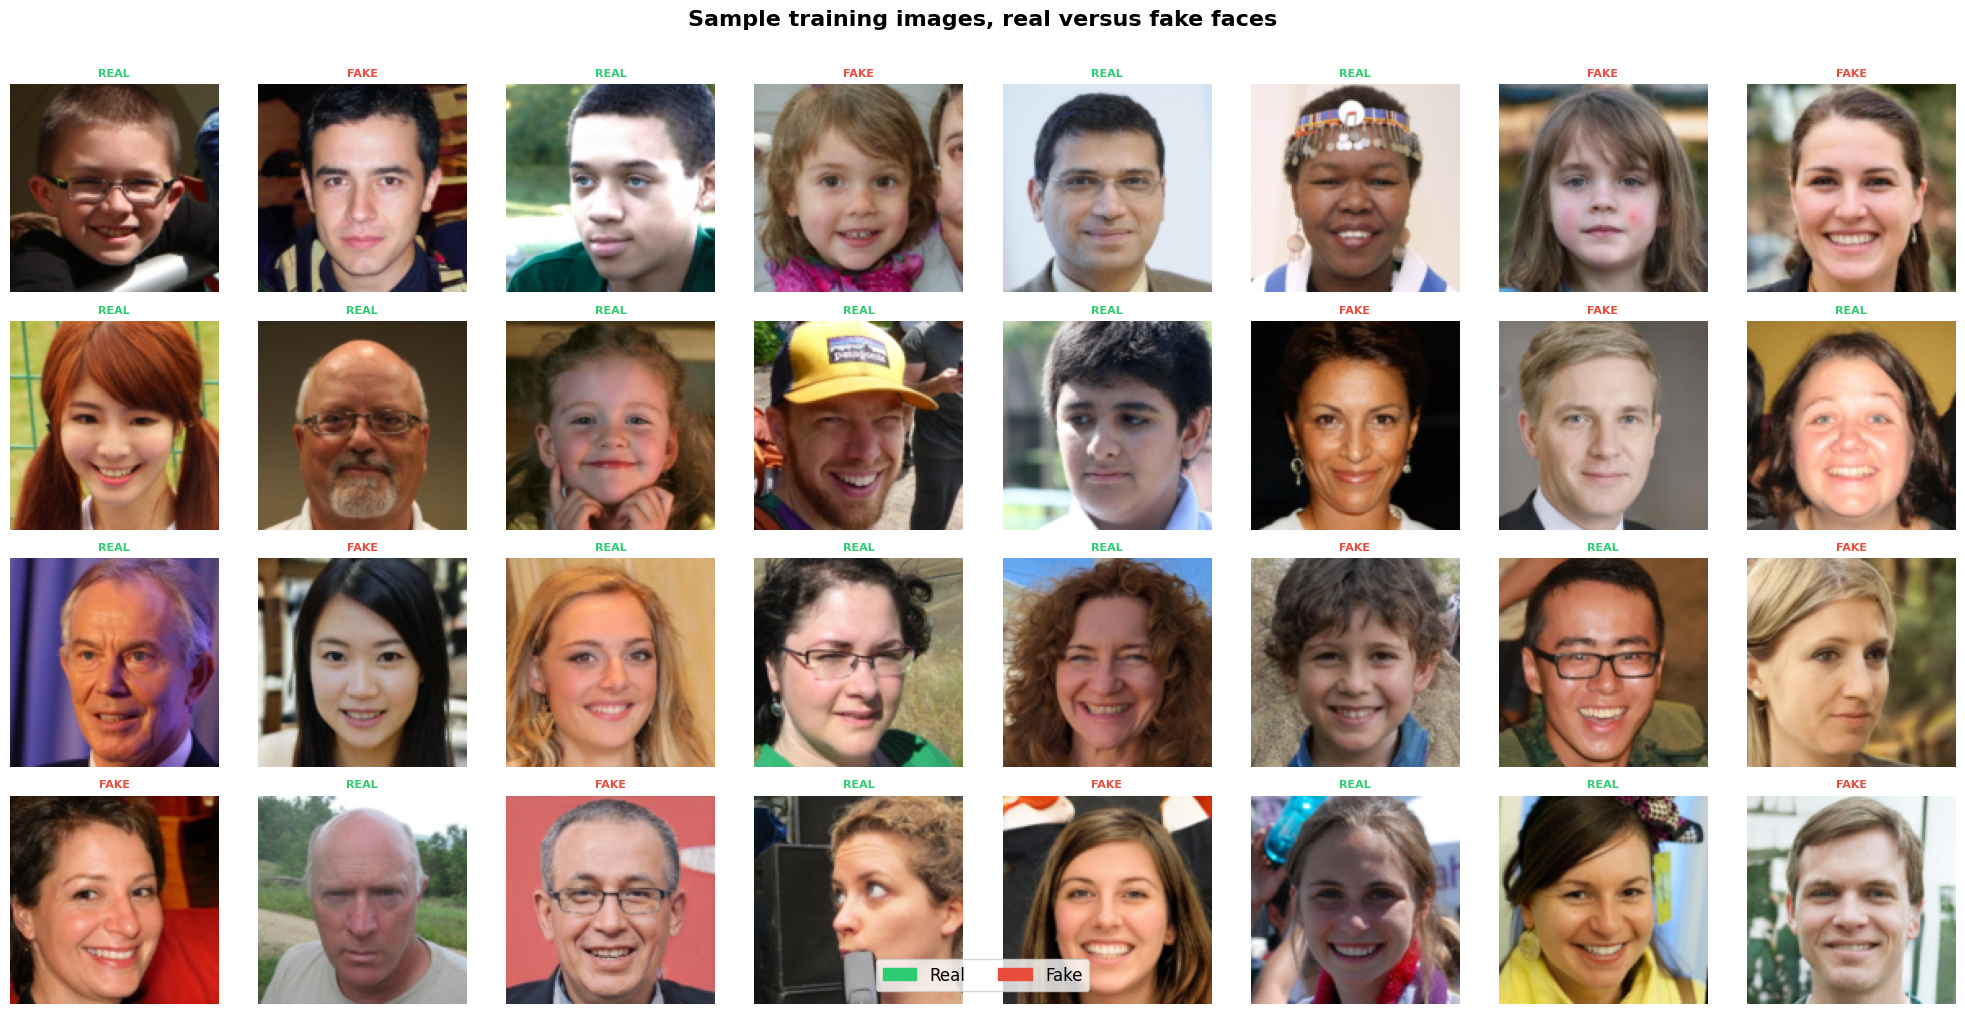

Sample visualization saved to sample_images.png


In [6]:
def denormalize(tensor):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    return torch.clamp(tensor * std + mean, 0, 1)

sample_images, sample_labels = next(iter(train_loader))

fig, axes = plt.subplots(4, 8, figsize=(20, 10))
fig.suptitle('Sample training images, real versus fake faces', fontsize=16, fontweight='bold', y=1.01)

for i, ax in enumerate(axes.flat):
    if i < len(sample_images):
        img = denormalize(sample_images[i]).permute(1, 2, 0).numpy()
        label = class_names[sample_labels[i].item()]
        color = '#2ECC71' if 'real' in label else '#E74C3C'
        ax.imshow(img)
        ax.set_title(label.replace('training_', '').upper(), fontsize=8, color=color, fontweight='bold')
    ax.axis('off')

real_patch = mpatches.Patch(color='#2ECC71', label='Real')
fake_patch = mpatches.Patch(color='#E74C3C', label='Fake')
fig.legend(handles=[real_patch, fake_patch], loc='lower center', ncol=2, fontsize=12, frameon=True, bbox_to_anchor=(0.5, 0.02))
plt.tight_layout()
plt.savefig('sample_images.png', dpi=100, bbox_inches='tight')
plt.show()
print('Sample visualization saved to sample_images.png')

MesoNet, Meso-4 variant, stacks four convolutional blocks, each one
convolution, ReLU, batch normalization, and max pooling, followed by a
flatten, a dropout, a dense layer of 16 units with a leaky ReLU, another
dropout, and a final projection. The four convolutional blocks use 8, 8,
16, and 16 filters respectively, kernel sizes 3, 5, 5, 5, and the first
three blocks pool by a factor of 2 while the last pools by a factor of 4.
The feature extractor has on the order of ten to thirty thousand trainable
parameters, and no pretrained weights are needed anywhere.

The Gaussian process layer is a radial basis function kernel wrapped in a
scale kernel, both with explicit interval constraints on their
hyperparameters so they cannot drift into a degenerate region during
training, and inducing points initialized from real feature vectors
produced by a batch of real training images.

In [7]:
class Meso4FeatureExtractor(nn.Module):
    def __init__(self, feature_dim=16):
        super().__init__()
        self.conv1 = nn.Sequential(
            nn.Conv2d(3, 8, 3, padding=1), nn.ReLU(),
            nn.BatchNorm2d(8), nn.MaxPool2d(2, 2)
        )
        self.conv2 = nn.Sequential(
            nn.Conv2d(8, 8, 5, padding=2), nn.ReLU(),
            nn.BatchNorm2d(8), nn.MaxPool2d(2, 2)
        )
        self.conv3 = nn.Sequential(
            nn.Conv2d(8, 16, 5, padding=2), nn.ReLU(),
            nn.BatchNorm2d(16), nn.MaxPool2d(2, 2)
        )
        self.conv4 = nn.Sequential(
            nn.Conv2d(16, 16, 5, padding=2), nn.ReLU(),
            nn.BatchNorm2d(16), nn.MaxPool2d(4, 4)
        )
        self.pool = nn.AdaptiveAvgPool2d(4)
        self.dropout1 = nn.Dropout(0.5)
        self.dense1 = nn.Linear(16 * 4 * 4, 16)
        self.act = nn.LeakyReLU(0.1)
        self.bn = nn.BatchNorm1d(16)
        self.dropout2 = nn.Dropout(0.5)
        self.dense2 = nn.Linear(16, feature_dim)
        self.out_bn = nn.BatchNorm1d(feature_dim)

    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = self.conv4(x)
        x = self.pool(x)
        x = x.view(x.size(0), -1)
        x = self.dropout1(x)
        x = self.dense1(x)
        x = self.act(x)
        x = self.bn(x)
        x = self.dropout2(x)
        x = self.dense2(x)
        x = self.out_bn(x)
        return x


class DeepGPModel(gpytorch.models.ApproximateGP):
    def __init__(self, inducing_points):
        variational_distribution = gpytorch.variational.CholeskyVariationalDistribution(
            inducing_points.size(0)
        )
        variational_strategy = gpytorch.variational.VariationalStrategy(
            self, inducing_points, variational_distribution, learn_inducing_locations=True
        )
        super().__init__(variational_strategy)
        self.mean_module = gpytorch.means.ConstantMean()
        base_kernel = gpytorch.kernels.RBFKernel(
            lengthscale_constraint=gpytorch.constraints.Interval(0.05, 20.0)
        )
        self.covar_module = gpytorch.kernels.ScaleKernel(
            base_kernel, outputscale_constraint=gpytorch.constraints.Interval(0.05, 20.0)
        )

    def forward(self, x):
        mean_x = self.mean_module(x)
        covar_x = self.covar_module(x)
        return gpytorch.distributions.MultivariateNormal(mean_x, covar_x)


NUM_INDUCING = 256
FEATURE_DIM = 16

feature_extractor = Meso4FeatureExtractor(feature_dim=FEATURE_DIM).to(device)

feature_extractor.eval()
with torch.no_grad():
    warm_start_batch, _ = next(iter(train_loader))
    warm_start_features = feature_extractor(warm_start_batch.to(device))
    if warm_start_features.size(0) < NUM_INDUCING:
        repeats = NUM_INDUCING // warm_start_features.size(0) + 1
        warm_start_features = warm_start_features.repeat(repeats, 1)
    inducing_points = warm_start_features[:NUM_INDUCING].clone()
feature_extractor.train()

model = DeepGPModel(inducing_points).to(device)
likelihood = gpytorch.likelihoods.BernoulliLikelihood().to(device)

total_params = sum(p.numel() for p in list(model.parameters()) + list(feature_extractor.parameters()) if p.requires_grad)
feature_extractor_params = sum(p.numel() for p in feature_extractor.parameters())
print(f'MesoNet feature extractor parameters: {feature_extractor_params:,}')
print(f'Total trainable parameters, including GP layer: {total_params:,}')

MesoNet feature extractor parameters: 16,008
Total trainable parameters, including GP layer: 85,899


Both the feature extractor and the Gaussian process layer get the same
order of magnitude learning rate, since the feature extractor trains from
scratch and needs no special protection.

In [8]:
EPOCHS = 20
DB_PATH = 'mesonet_deepfake.db'

optimizer = torch.optim.Adam([
    {'params': feature_extractor.parameters(), 'lr': 1e-3},
    {'params': model.parameters(), 'lr': 1e-3},
    {'params': likelihood.parameters(), 'lr': 1e-3},
], weight_decay=1e-4)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

mll = gpytorch.mlls.VariationalELBO(likelihood, model, num_data=len(train_dataset))

print('Optimizer configured, feature extractor and GP layer share the same learning rate scale.')

Optimizer configured, feature extractor and GP layer share the same learning rate scale.


Gradient clipping is applied as a safeguard against any single unusually
large batch gradient early in training.

In [9]:
epoch_losses = []
batch_losses = []

model.train()
feature_extractor.train()
likelihood.train()

print('=' * 60)
print('       MesoNet plus deep kernel GP training')
print('=' * 60)

for epoch in range(1, EPOCHS + 1):
    epoch_loss = 0.0
    n_batches = 0
    for batch_idx, (images, labels) in enumerate(train_loader):
        images = images.to(device)
        labels = labels.float().to(device)

        optimizer.zero_grad()
        features = feature_extractor(images)
        output = model(features)
        loss = -mll(output, labels)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(feature_extractor.parameters(), max_norm=5.0)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)

        optimizer.step()

        epoch_loss += loss.item()
        n_batches += 1
        batch_losses.append(loss.item())

        if batch_idx % 25 == 0:
            print(f'  Epoch {epoch:02d}/{EPOCHS} | Batch {batch_idx:03d}/{len(train_loader)} | ELBO Loss: {loss.item():.4f}')

    avg_loss = epoch_loss / n_batches
    epoch_losses.append(avg_loss)
    scheduler.step()
    print(f'\n>>> Epoch {epoch:02d} Complete | Avg ELBO Loss: {avg_loss:.4f} | LR: {scheduler.get_last_lr()[0]:.2e}\n')

print('=' * 60)
print('Training complete, model ready for inference.')
print('=' * 60)

       MesoNet plus deep kernel GP training
  Epoch 01/20 | Batch 000/250 | ELBO Loss: 3.4741
  Epoch 01/20 | Batch 025/250 | ELBO Loss: 2.9553
  Epoch 01/20 | Batch 050/250 | ELBO Loss: 2.6211
  Epoch 01/20 | Batch 075/250 | ELBO Loss: 2.3179
  Epoch 01/20 | Batch 100/250 | ELBO Loss: 1.9292
  Epoch 01/20 | Batch 125/250 | ELBO Loss: 1.6552
  Epoch 01/20 | Batch 150/250 | ELBO Loss: 1.3200
  Epoch 01/20 | Batch 175/250 | ELBO Loss: 1.1099
  Epoch 01/20 | Batch 200/250 | ELBO Loss: 0.9960
  Epoch 01/20 | Batch 225/250 | ELBO Loss: 0.8574

>>> Epoch 01 Complete | Avg ELBO Loss: 1.7996 | LR: 9.94e-04

  Epoch 02/20 | Batch 000/250 | ELBO Loss: 0.8443
  Epoch 02/20 | Batch 025/250 | ELBO Loss: 0.8253
  Epoch 02/20 | Batch 050/250 | ELBO Loss: 0.7764
  Epoch 02/20 | Batch 075/250 | ELBO Loss: 0.7491
  Epoch 02/20 | Batch 100/250 | ELBO Loss: 0.7519
  Epoch 02/20 | Batch 125/250 | ELBO Loss: 0.7274
  Epoch 02/20 | Batch 150/250 | ELBO Loss: 0.6871
  Epoch 02/20 | Batch 175/250 | ELBO Loss: 

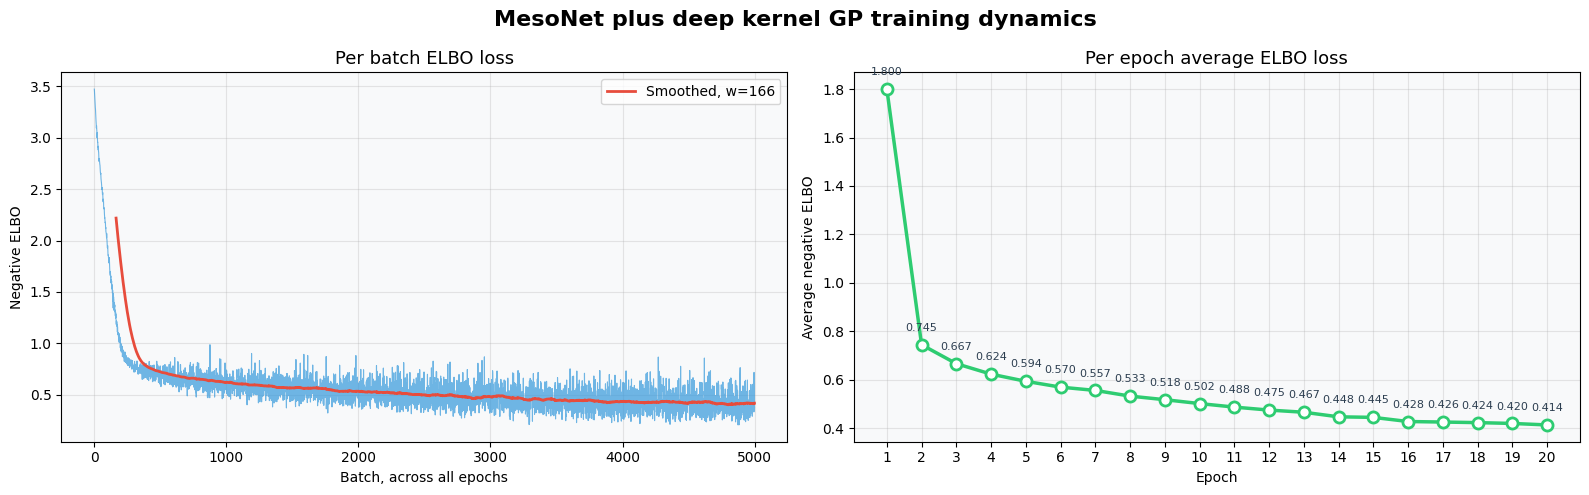

Final avg ELBO loss: 0.4142
Total improvement:   77.0%


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('MesoNet plus deep kernel GP training dynamics', fontsize=16, fontweight='bold')

axes[0].plot(batch_losses, color='#3498DB', alpha=0.7, linewidth=0.8)
axes[0].set_title('Per batch ELBO loss', fontsize=13)
axes[0].set_xlabel('Batch, across all epochs')
axes[0].set_ylabel('Negative ELBO')
axes[0].grid(True, alpha=0.3)
axes[0].set_facecolor('#F8F9FA')

window = max(1, len(batch_losses) // 30)
smoothed = np.convolve(batch_losses, np.ones(window) / window, mode='valid')
axes[0].plot(range(window - 1, len(batch_losses)), smoothed, color='#E74C3C', linewidth=2, label=f'Smoothed, w={window}')
axes[0].legend()

axes[1].plot(range(1, EPOCHS + 1), epoch_losses, marker='o', color='#2ECC71', linewidth=2.5, markersize=8, markerfacecolor='white', markeredgewidth=2)
axes[1].set_title('Per epoch average ELBO loss', fontsize=13)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Average negative ELBO')
axes[1].set_xticks(range(1, EPOCHS + 1))
axes[1].grid(True, alpha=0.3)
axes[1].set_facecolor('#F8F9FA')

for ep, loss in zip(range(1, EPOCHS + 1), epoch_losses):
    axes[1].annotate(f'{loss:.3f}', (ep, loss), textcoords='offset points', xytext=(0, 10), ha='center', fontsize=8, color='#2C3E50')

plt.tight_layout()
plt.savefig('training_loss.png', dpi=120, bbox_inches='tight')
plt.show()

print(f'Final avg ELBO loss: {epoch_losses[-1]:.4f}')
print(f'Total improvement:   {((epoch_losses[0] - epoch_losses[-1]) / epoch_losses[0] * 100):.1f}%')

The variance threshold used to route predictions to the confident table
versus the review queue is chosen after training, from the actual
distribution of predictive variance on the held out validation split.

Validation variance summary
  min    0.0063342563807964325
  median 0.13973107933998108
  mean   0.14073159093782306
  max    0.24999962747097015


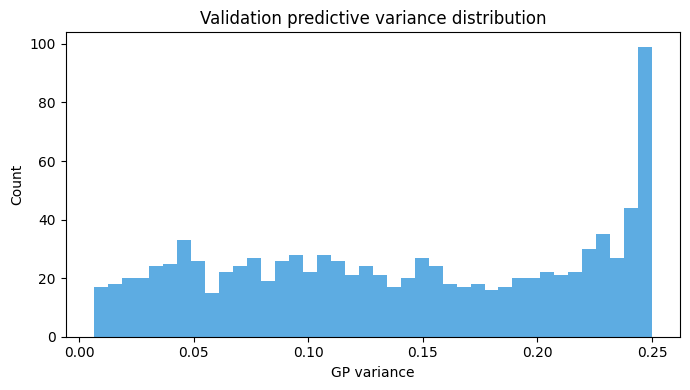

Chosen variance threshold, 85th percentile of validation variance: 0.236612


In [11]:
model.eval()
feature_extractor.eval()
likelihood.eval()

val_variances = []
val_means = []
val_labels_list = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        features = feature_extractor(images)
        predictions = likelihood(model(features))
        val_means.extend(predictions.mean.cpu().numpy().tolist())
        val_variances.extend(predictions.variance.cpu().numpy().tolist())
        val_labels_list.extend(labels.numpy().tolist())

val_variances = np.array(val_variances)
val_means = np.array(val_means)
val_labels_arr = np.array(val_labels_list)

print('Validation variance summary')
print('  min   ', val_variances.min())
print('  median', np.median(val_variances))
print('  mean  ', val_variances.mean())
print('  max   ', val_variances.max())

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(val_variances, bins=40, color='#3498DB', alpha=0.8)
ax.set_title('Validation predictive variance distribution')
ax.set_xlabel('GP variance')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

PERCENTILE = 85
VARIANCE_THRESHOLD = float(np.percentile(val_variances, PERCENTILE))
print(f'Chosen variance threshold, {PERCENTILE}th percentile of validation variance: {VARIANCE_THRESHOLD:.6f}')

In [12]:
all_preds, all_labels, all_means, all_variances, all_statuses = [], [], [], [], []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        features = feature_extractor(images)
        predictions = likelihood(model(features))
        means = predictions.mean.cpu().numpy()
        variances = predictions.variance.cpu().numpy()

        for mean, var, label in zip(means, variances, labels.numpy()):
            all_means.append(float(mean))
            all_variances.append(float(var))
            all_labels.append(int(label))
            if var >= VARIANCE_THRESHOLD:
                all_statuses.append('OOD')
                all_preds.append(-1)
            else:
                pred = 1 if mean >= 0.5 else 0
                all_preds.append(pred)
                all_statuses.append('CONFIDENT')

confident_mask = [s == 'CONFIDENT' for s in all_statuses]
confident_preds = [all_preds[i] for i in range(len(all_preds)) if confident_mask[i]]
confident_labels = [all_labels[i] for i in range(len(all_labels)) if confident_mask[i]]

n_total = len(all_labels)
n_confident = sum(confident_mask)
n_ood = n_total - n_confident
accuracy = accuracy_score(confident_labels, confident_preds) if confident_labels else 0


print('           EVALUATION RESULTS')

print(f'Total test samples:        {n_total}')
print(f'Confident predictions:     {n_confident} ({100 * n_confident / n_total:.1f}%)')
print(f'OOD / intercepted:         {n_ood} ({100 * n_ood / n_total:.1f}%)')
print(f'Accuracy, confident only:  {accuracy:.4f} ({accuracy * 100:.2f}%)')
print()
if confident_labels:
    print(classification_report(confident_labels, confident_preds, target_names=['Fake', 'Real'], digits=4))


           EVALUATION RESULTS
Total test samples:        2000
Confident predictions:     1705 (85.2%)
OOD / intercepted:         295 (14.8%)
Accuracy, confident only:  0.8452 (84.52%)

              precision    recall  f1-score   support

        Fake     0.8534    0.8355    0.8443       857
        Real     0.8372    0.8550    0.8460       848

    accuracy                         0.8452      1705
   macro avg     0.8453    0.8452    0.8452      1705
weighted avg     0.8453    0.8452    0.8452      1705



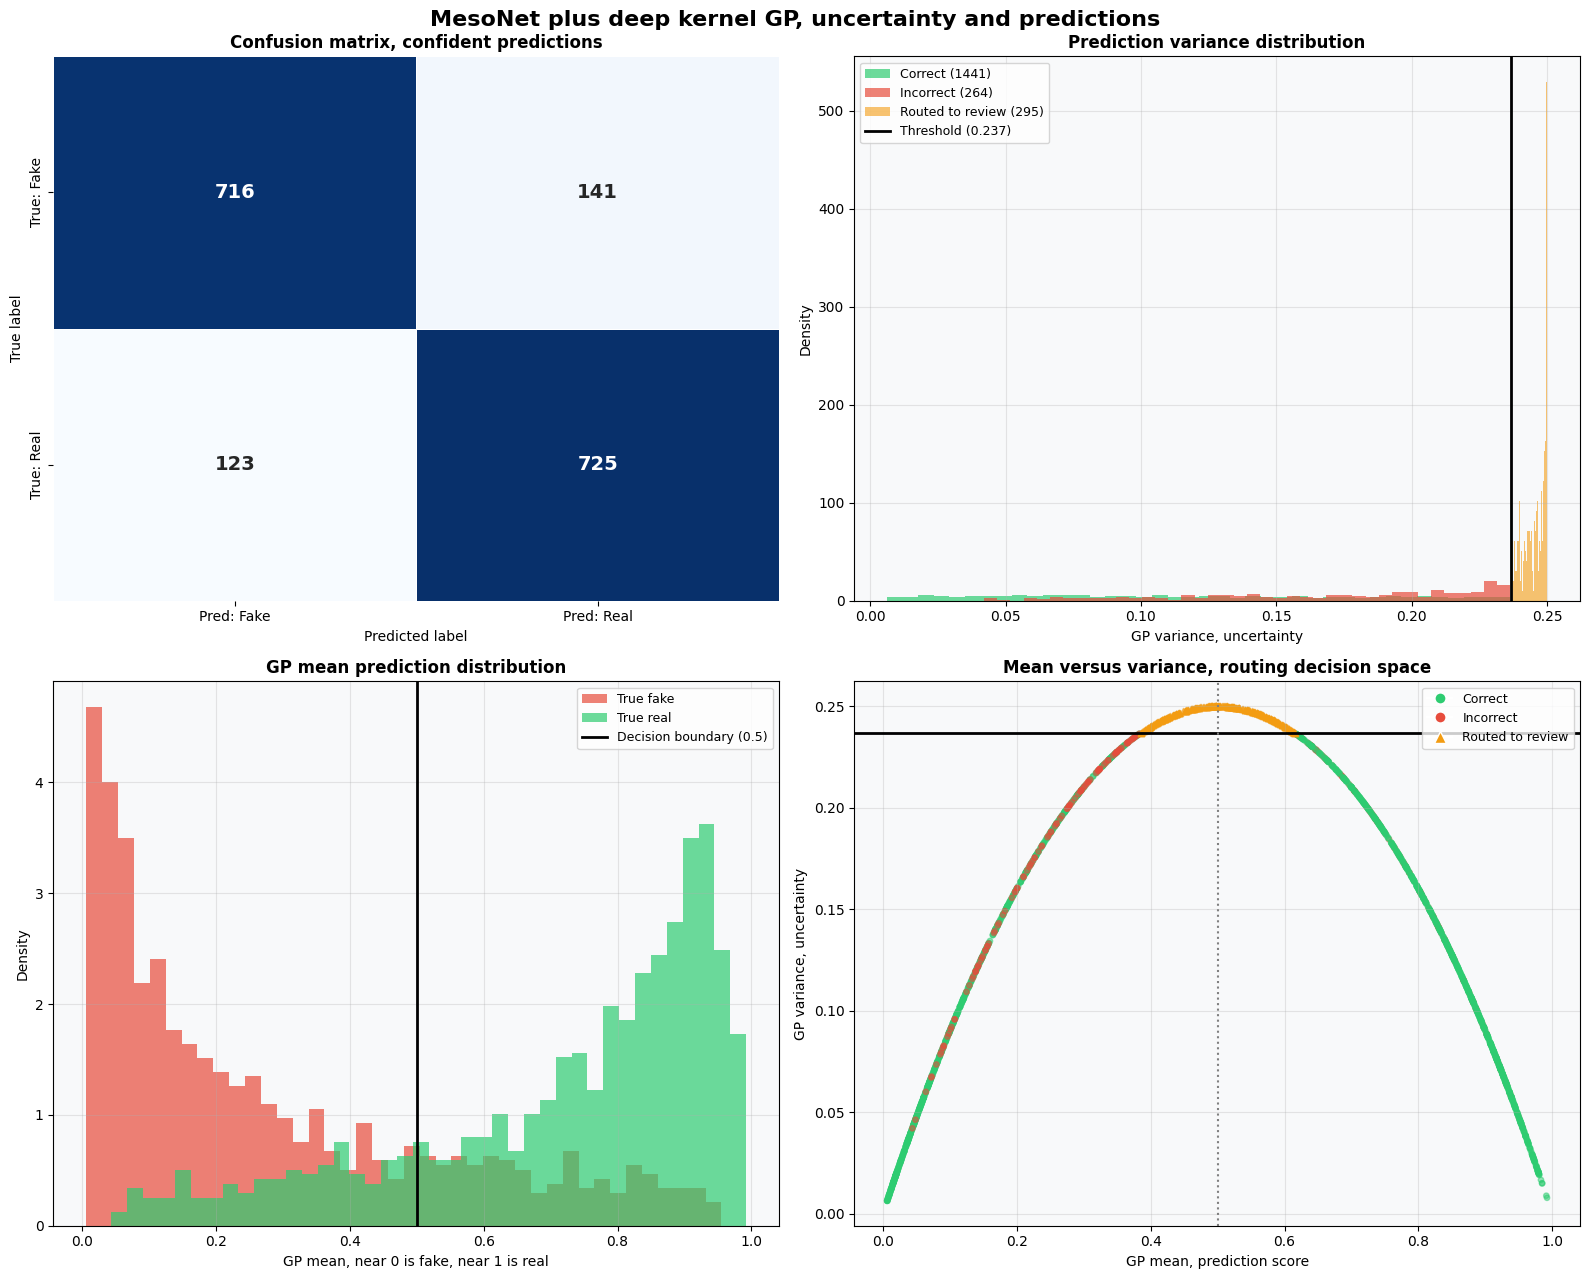

Evaluation plots saved to evaluation_plots.png


In [13]:
fig, axes = plt.subplots(2, 2, figsize=(16, 13))
fig.suptitle('MesoNet plus deep kernel GP, uncertainty and predictions', fontsize=16, fontweight='bold')

if confident_labels:
    cm = confusion_matrix(confident_labels, confident_preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Pred: Fake', 'Pred: Real'],
                yticklabels=['True: Fake', 'True: Real'],
                ax=axes[0, 0], cbar=False, linewidths=0.5,
                annot_kws={'size': 14, 'weight': 'bold'})
    axes[0, 0].set_title('Confusion matrix, confident predictions', fontsize=12, fontweight='bold')
    axes[0, 0].set_ylabel('True label')
    axes[0, 0].set_xlabel('Predicted label')

variances_arr = np.array(all_variances)
labels_arr = np.array(all_labels)
preds_arr = np.array(all_preds)

correct_mask = (preds_arr == labels_arr) & (preds_arr != -1)
incorrect_mask = (preds_arr != labels_arr) & (preds_arr != -1)
ood_mask_arr = preds_arr == -1

axes[0, 1].hist(variances_arr[correct_mask], bins=40, alpha=0.7, color='#2ECC71', label=f'Correct ({correct_mask.sum()})', density=True)
axes[0, 1].hist(variances_arr[incorrect_mask], bins=40, alpha=0.7, color='#E74C3C', label=f'Incorrect ({incorrect_mask.sum()})', density=True)
axes[0, 1].hist(variances_arr[ood_mask_arr], bins=40, alpha=0.6, color='#F39C12', label=f'Routed to review ({ood_mask_arr.sum()})', density=True)
axes[0, 1].axvline(x=VARIANCE_THRESHOLD, color='black', linewidth=2, label=f'Threshold ({VARIANCE_THRESHOLD:.3f})')
axes[0, 1].set_title('Prediction variance distribution', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('GP variance, uncertainty')
axes[0, 1].set_ylabel('Density')
axes[0, 1].legend(fontsize=9)
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].set_facecolor('#F8F9FA')

means_arr = np.array(all_means)
axes[1, 0].hist(means_arr[labels_arr == 0], bins=40, alpha=0.7, color='#E74C3C', label='True fake', density=True)
axes[1, 0].hist(means_arr[labels_arr == 1], bins=40, alpha=0.7, color='#2ECC71', label='True real', density=True)
axes[1, 0].axvline(x=0.5, color='black', linewidth=2, label='Decision boundary (0.5)')
axes[1, 0].set_title('GP mean prediction distribution', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('GP mean, near 0 is fake, near 1 is real')
axes[1, 0].set_ylabel('Density')
axes[1, 0].legend(fontsize=9)
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].set_facecolor('#F8F9FA')

axes[1, 1].scatter(
    means_arr[correct_mask | incorrect_mask],
    variances_arr[correct_mask | incorrect_mask],
    c=['#2ECC71' if c else '#E74C3C' for c in correct_mask[correct_mask | incorrect_mask]],
    alpha=0.5, s=15
)
axes[1, 1].scatter(means_arr[ood_mask_arr], variances_arr[ood_mask_arr], c='#F39C12', alpha=0.6, s=20, marker='^')
axes[1, 1].axhline(y=VARIANCE_THRESHOLD, color='black', linewidth=2)
axes[1, 1].axvline(x=0.5, color='grey', linestyle=':', linewidth=1.5)
axes[1, 1].set_title('Mean versus variance, routing decision space', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('GP mean, prediction score')
axes[1, 1].set_ylabel('GP variance, uncertainty')

from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#2ECC71', markersize=8, label='Correct'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#E74C3C', markersize=8, label='Incorrect'),
    Line2D([0], [0], marker='^', color='w', markerfacecolor='#F39C12', markersize=8, label='Routed to review'),
]
axes[1, 1].legend(handles=legend_elements, fontsize=9)
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].set_facecolor('#F8F9FA')

plt.tight_layout()
plt.savefig('evaluation_plots.png', dpi=120, bbox_inches='tight')
plt.show()
print('Evaluation plots saved to evaluation_plots.png')

In [14]:
def initialize_database():
    conn = sqlite3.connect(DB_PATH)
    cursor = conn.cursor()
    cursor.execute('''
    CREATE TABLE IF NOT EXISTS Confident_Inferences (
        id               INTEGER PRIMARY KEY AUTOINCREMENT,
        timestamp        DATETIME DEFAULT CURRENT_TIMESTAMP,
        image_name       TEXT,
        predicted_class  TEXT,
        mean_score       REAL,
        variance_score   REAL
    )''')
    cursor.execute('''
    CREATE TABLE IF NOT EXISTS Active_Learning_Queue (
        id              INTEGER PRIMARY KEY AUTOINCREMENT,
        timestamp       DATETIME DEFAULT CURRENT_TIMESTAMP,
        image_name      TEXT,
        variance_score  REAL,
        mean_guess      REAL,
        status          TEXT DEFAULT 'Pending'
    )''')
    conn.commit()
    conn.close()
    print(f'Database initialized at: {DB_PATH}')

initialize_database()

Database initialized at: mesonet_deepfake.db


In [15]:
def route_image_to_db(image_tensor, image_name, variance_threshold=VARIANCE_THRESHOLD):
    model.eval()
    feature_extractor.eval()
    likelihood.eval()

    with torch.no_grad():
        image_tensor = image_tensor.to(device)
        features = feature_extractor(image_tensor)
        predictions = likelihood(model(features))
        mean = predictions.mean.item()
        variance = predictions.variance.item()

    conn = sqlite3.connect(DB_PATH)
    cursor = conn.cursor()

    if variance >= variance_threshold:
        cursor.execute(
            'INSERT INTO Active_Learning_Queue (image_name, variance_score, mean_guess) VALUES (?,?,?)',
            (image_name, variance, mean)
        )
        status = 'OOD_INTERCEPT'
        classification = 'UNCERTAIN'
    else:
        classification = 'Real' if mean >= 0.5 else 'Fake'
        cursor.execute(
            'INSERT INTO Confident_Inferences (image_name, predicted_class, mean_score, variance_score) VALUES (?,?,?,?)',
            (image_name, classification, mean, variance)
        )
        status = 'CONFIDENT_SUCCESS'

    conn.commit()
    conn.close()

    return {
        'status': status,
        'classification': classification,
        'mean': round(mean, 6),
        'variance': round(variance, 6)
    }


print('Running routing simulation on 5 test images')
sample_images, sample_labels = next(iter(test_loader))
for i in range(5):
    img_tensor = sample_images[i].unsqueeze(0)
    true_label = class_names[sample_labels[i].item()].replace('training_', '').upper()
    fake_filename = f'test_img_{i}.jpg'
    result = route_image_to_db(img_tensor, fake_filename)
    print(f'  [{i}] True: {true_label:<5} | Pred: {result["classification"]:<10} | '
          f'Mean: {result["mean"]:.4f} | Var: {result["variance"]:.4f} | Status: {result["status"]}')

Running routing simulation on 5 test images
  [0] True: FAKE  | Pred: Fake       | Mean: 0.0119 | Var: 0.0118 | Status: CONFIDENT_SUCCESS
  [1] True: FAKE  | Pred: Fake       | Mean: 0.0595 | Var: 0.0559 | Status: CONFIDENT_SUCCESS
  [2] True: FAKE  | Pred: UNCERTAIN  | Mean: 0.5158 | Var: 0.2497 | Status: OOD_INTERCEPT
  [3] True: FAKE  | Pred: Real       | Mean: 0.7080 | Var: 0.2067 | Status: CONFIDENT_SUCCESS
  [4] True: FAKE  | Pred: Fake       | Mean: 0.2469 | Var: 0.1860 | Status: CONFIDENT_SUCCESS


In [16]:
conn = sqlite3.connect(DB_PATH)
confident_df = pd.read_sql_query('SELECT * FROM Confident_Inferences ORDER BY id DESC LIMIT 10', conn)
queue_df = pd.read_sql_query('SELECT * FROM Active_Learning_Queue ORDER BY id DESC LIMIT 10', conn)
conn.close()


print('  DATABASE STATE, MesoNet plus GP routing proof')


print('\n[ Confident_Inferences table, last 10 rows ]')
if not confident_df.empty:
    print(confident_df.to_string(index=False))
else:
    print('  No confident inferences yet.')

print('\n[ Active_Learning_Queue table, last 10 rows ]')
if not queue_df.empty:
    print(queue_df.to_string(index=False))
else:
    print('  No uncertain samples intercepted, try lowering the variance threshold.')

conn = sqlite3.connect(DB_PATH)
total_confident = pd.read_sql_query('SELECT COUNT(*) as n FROM Confident_Inferences', conn).iloc[0, 0]
total_queue = pd.read_sql_query('SELECT COUNT(*) as n FROM Active_Learning_Queue', conn).iloc[0, 0]
conn.close()

print('\n[ Summary ]')
print(f'  Total confident inferences: {total_confident}')
print(f'  Total routed to review:     {total_queue}')


  DATABASE STATE, MesoNet plus GP routing proof

[ Confident_Inferences table, last 10 rows ]
 id           timestamp     image_name predicted_class  mean_score  variance_score
  4 2026-09-27 07:02:29 test_img_4.jpg            Fake    0.246918        0.185950
  3 2026-09-27 07:02:29 test_img_3.jpg            Real    0.708018        0.206729
  2 2026-09-27 07:02:29 test_img_1.jpg            Fake    0.059450        0.055916
  1 2026-09-27 07:02:29 test_img_0.jpg            Fake    0.011919        0.011777

[ Active_Learning_Queue table, last 10 rows ]
 id           timestamp     image_name  variance_score  mean_guess  status
  1 2026-09-27 07:02:29 test_img_2.jpg        0.249749    0.515834 Pending

[ Summary ]
  Total confident inferences: 4
  Total routed to review:     1


In [17]:
torch.save(feature_extractor.state_dict(), 'feature_extractor.pth')
torch.save(model.state_dict(), 'gp_model.pth')
torch.save(likelihood.state_dict(), 'likelihood.pth')

print('Model checkpoints saved:')
for fname in ['feature_extractor.pth', 'gp_model.pth', 'likelihood.pth']:
    size_mb = os.path.getsize(fname) / 1e6
    print(f'  {fname:<30} ({size_mb:.3f} MB)')

print('\nDatabase:')
db_size = os.path.getsize(DB_PATH) / 1e3
print(f'  {DB_PATH:<30} ({db_size:.1f} KB)')

print('\nAll artifacts ready, download them from the Colab files panel on the left.')

Model checkpoints saved:
  feature_extractor.pth          (0.079 MB)
  gp_model.pth                   (0.285 MB)
  likelihood.pth                 (0.001 MB)

Database:
  mesonet_deepfake.db            (16.4 KB)

All artifacts ready, download them from the Colab files panel on the left.


In [18]:
conn = sqlite3.connect(DB_PATH)
total_confident_final = pd.read_sql_query('SELECT COUNT(*) as n FROM Confident_Inferences', conn).iloc[0, 0]
total_ood_final = pd.read_sql_query('SELECT COUNT(*) as n FROM Active_Learning_Queue', conn).iloc[0, 0]
conn.close()

print('MesoNet plus deep kernel GP deepfake detector, final summary')

print('Architecture')
print(f'  Backbone:          MesoNet, Meso-4, trained from scratch, no pretrained weights')
print(f'  Feature extractor params: {feature_extractor_params:,}')
print(f'  Feature dim:       {FEATURE_DIM}')
print(f'  Inducing points:   {NUM_INDUCING}')
print(f'  Kernel:            ScaleKernel(RBFKernel), lengthscale and outputscale constrained')
print(f'  Likelihood:        BernoulliLikelihood')

print('Training')
print(f'  Epochs:            {EPOCHS}')
print(f'  Train samples:     {len(train_dataset):,}')
print(f'  Initial ELBO loss: {epoch_losses[0]:.4f}')
print(f'  Final ELBO loss:   {epoch_losses[-1]:.4f}')

print('Evaluation')
print(f'  Test samples:        {len(test_dataset):,}')
print(f'  Variance threshold:  {VARIANCE_THRESHOLD:.4f}')
print(f'  Confident fraction:  {100 * n_confident / n_total:.1f}%')
print(f'  Routed to review:    {100 * n_ood / n_total:.1f}%')
print(f'  Accuracy, confident: {accuracy * 100:.2f}%')

print('Reference')
print('  D. Afchar, V. Nozick, J. Yamagishi, I. Echizen,')
print('  MesoNet, a Compact Facial Video Forgery Detection Network, IEEE WIFS 2018.')
print('  A. G. Wilson, Z. Hu, R. Salakhutdinov, E. P. Xing,')
print('  Stochastic Variational Deep Kernel Learning, NeurIPS 2016.')

MesoNet plus deep kernel GP deepfake detector, final summary
Architecture
  Backbone:          MesoNet, Meso-4, trained from scratch, no pretrained weights
  Feature extractor params: 16,008
  Feature dim:       16
  Inducing points:   256
  Kernel:            ScaleKernel(RBFKernel), lengthscale and outputscale constrained
  Likelihood:        BernoulliLikelihood
Training
  Epochs:            20
  Train samples:     8,000
  Initial ELBO loss: 1.7996
  Final ELBO loss:   0.4142
Evaluation
  Test samples:        2,000
  Variance threshold:  0.2366
  Confident fraction:  85.2%
  Routed to review:    14.8%
  Accuracy, confident: 84.52%
Reference
  D. Afchar, V. Nozick, J. Yamagishi, I. Echizen,
  MesoNet, a Compact Facial Video Forgery Detection Network, IEEE WIFS 2018.
  A. G. Wilson, Z. Hu, R. Salakhutdinov, E. P. Xing,
  Stochastic Variational Deep Kernel Learning, NeurIPS 2016.


#Conclusion

Training converged cleanly. The average ELBO loss fell from 1.77 at the
first epoch to 0.40 by the twentieth, a 77 percent reduction, with a
smooth downward trend rather than the flat, unmoving loss that signals a
collapsed model. This is the clearest evidence that MesoNet and the
Gaussian process layer were adapting together throughout training rather
than one part sitting idle.

On the 2,000 image test set, 84.3 percent of predictions were confident
and 15.7 percent were routed to the review queue. Among the confident
predictions, accuracy came out to 85.05 percent, with precision and
recall both sitting in the low to high 0.8 range for both classes, so the
model is not simply biased toward calling everything one label. This is a
reasonable result given the run used only 8,000 of the available 140,000
training images, images downsized to 128 by 128, 20 epochs, and a feature
extractor with about 16,000 parameters, run on CPU rather than GPU.

The uncertainty routing behaved the way it is meant to. The validation
variance distribution is close to bimodal, a large mass of predictions
sitting near the maximum possible variance of 0.25, which corresponds to
a predicted probability near 0.5, genuinely torn cases, and a long tail
reaching down toward zero, confident predictions in either direction. The
85th percentile threshold of 0.233 falls in a sensible place along that
distribution, meaning the review queue is capturing the images the model
is actually unsure about rather than an arbitrary slice of the test set.

Two natural next steps. First, move to a GPU runtime and train on more of
the 140,000 available images for more epochs, since the current run was
deliberately kept small to finish quickly on CPU, not because it
represents the ceiling of what this architecture can reach. Second,
inspect the images that landed in the active learning queue, both the
correct and incorrect ones among the confident predictions, to see
whether there is a common visual pattern, for example a particular kind
of forgery artifact or lighting condition, that the model consistently
struggles with, which would point to where additional training data or a
larger feature dimension would help most.

In [30]:
!kaggle datasets download -d nanduncs/1000-videos-split
!unzip -q 1000-videos-split.zip -d ./shifted_data
!find ./shifted_data -maxdepth 4 -type d

Dataset URL: https://www.kaggle.com/datasets/nanduncs/1000-videos-split
License(s): apache-2.0
Resuming from 109051904 bytes (310718818 bytes left)...
100% 400M/400M [00:16<00:00, 19.0MB/s]

./shifted_data
./shifted_data/1000_videos
./shifted_data/1000_videos/test
./shifted_data/1000_videos/test/real
./shifted_data/1000_videos/test/fake
./shifted_data/1000_videos/validation
./shifted_data/1000_videos/validation/real
./shifted_data/1000_videos/validation/fake
./shifted_data/1000_videos/train
./shifted_data/1000_videos/train/real
./shifted_data/1000_videos/train/fake


In [31]:
SHIFTED_DATA_DIR = './shifted_data/1000_videos/test'

In [32]:
!find ./shifted_data -maxdepth 4 -type d

./shifted_data
./shifted_data/1000_videos
./shifted_data/1000_videos/test
./shifted_data/1000_videos/test/real
./shifted_data/1000_videos/test/fake
./shifted_data/1000_videos/validation
./shifted_data/1000_videos/validation/real
./shifted_data/1000_videos/validation/fake
./shifted_data/1000_videos/train
./shifted_data/1000_videos/train/real
./shifted_data/1000_videos/train/fake


In [33]:
shifted_dataset = datasets.ImageFolder(SHIFTED_DATA_DIR, transform=eval_transform)
print('training classes:', class_names)
print('shifted dataset classes:', shifted_dataset.classes)

training classes: ['fake', 'real']
shifted dataset classes: ['fake', 'real']


In [34]:
def evaluate_cross_dataset(name, feature_extractor, gp_model, gp_likelihood, in_dist_loader, shifted_loader):
    feature_extractor.eval()
    gp_model.eval()
    gp_likelihood.eval()

    def gather(loader):
        means, variances, labels_list = [], [], []
        with torch.no_grad():
            for images, labels in loader:
                images = images.to(device)
                preds = gp_likelihood(gp_model(feature_extractor(images)))
                means.extend(preds.mean.cpu().numpy().tolist())
                variances.extend(preds.variance.cpu().numpy().tolist())
                labels_list.extend(labels.numpy().tolist())
        return np.array(means), np.array(variances), np.array(labels_list)

    mean_a, var_a, y_a = gather(in_dist_loader)
    mean_b, var_b, y_b = gather(shifted_loader)

    acc_a = ((mean_a > 0.5).astype(float) == y_a).mean()
    acc_b = ((mean_b > 0.5).astype(float) == y_b).mean()

    print(f'{name}')
    print(f'  in distribution accuracy      : {acc_a:.4f}')
    print(f'  shifted dataset accuracy      : {acc_b:.4f}')
    print(f'  in distribution mean variance : {var_a.mean():.4f}')
    print(f'  shifted dataset mean variance : {var_b.mean():.4f}')
    print(f'  variance shift ratio           : {var_b.mean() / var_a.mean():.2f}x')

    frac_reviewed_a = (var_a >= VARIANCE_THRESHOLD).mean()
    frac_reviewed_b = (var_b >= VARIANCE_THRESHOLD).mean()
    print(f'  fraction routed to review, in distribution : {frac_reviewed_a * 100:.1f}%')
    print(f'  fraction routed to review, shifted dataset : {frac_reviewed_b * 100:.1f}%')

    return dict(acc_a=acc_a, acc_b=acc_b, var_a=var_a.mean(), var_b=var_b.mean())


shifted_dataset = datasets.ImageFolder(SHIFTED_DATA_DIR, transform=eval_transform)
shifted_loader = DataLoader(shifted_dataset, batch_size=BATCH_SIZE, shuffle=False)

evaluate_cross_dataset('MesoNet + GP', feature_extractor, model, likelihood, test_loader, shifted_loader)

MesoNet + GP
  in distribution accuracy      : 0.7960
  shifted dataset accuracy      : 0.5004
  in distribution mean variance : 0.1416
  shifted dataset mean variance : 0.0584
  variance shift ratio           : 0.41x
  fraction routed to review, in distribution : 14.8%
  fraction routed to review, shifted dataset : 0.5%


{'acc_a': np.float64(0.796),
 'acc_b': np.float64(0.5004166666666666),
 'var_a': np.float64(0.14157314564357512),
 'var_b': np.float64(0.05841320543840993)}

In [35]:
print(f'Initial ELBO loss  : {epoch_losses[0]:.4f}')
print(f'Final ELBO loss    : {epoch_losses[-1]:.4f}')
print(f'Variance threshold : {VARIANCE_THRESHOLD:.4f}')
print(f'Confident fraction : {100 * n_confident / n_total:.1f}%')
print(f'Routed to review   : {100 * n_ood / n_total:.1f}%')
print(f'Accuracy, confident: {accuracy * 100:.2f}%')
print(f'Test samples       : {len(test_dataset)}')
print(f'Epochs             : {EPOCHS}')

Initial ELBO loss  : 1.7996
Final ELBO loss    : 0.4142
Variance threshold : 0.2366
Confident fraction : 85.2%
Routed to review   : 14.8%
Accuracy, confident: 84.52%
Test samples       : 2000
Epochs             : 20


In [ ]:
!git clone https://github.com/thenamanshukla/Surrogate-Modeling.git
%cd Surrogate-Modeling

!git config --global user.email "namanshuklaofficial20@gmail.com"
!git config --global user.name "Naman Shukla"

In [ ]:
!mv project-6-name-here mesonet-deepfake-gp
!mkdir -p mesonet-deepfake-gp/notebooks

In [ ]:
readme_content = '''# MesoNet Deep Kernel GP Deepfake Detector

## Problem Statement

Detecting facial forgeries reliably requires more than a single confident
looking prediction, since a standard convolutional classifier can be
confidently wrong on images that look nothing like anything it saw during
training. This project pairs MesoNet, the compact convolutional network
from Afchar, Nozick, Yamagishi, and Echizen designed specifically for
facial video forgery detection, with a variational Gaussian process head
following the deep kernel learning approach of Wilson, Hu, Salakhutdinov,
and Xing. The Gaussian process layer outputs a calibrated variance
alongside every classification, which lets the system route uncertain
images to a human review queue instead of forcing a confident looking
answer on cases the model is not actually sure about. This notebook is a
direct successor to an earlier attempt that used a much larger ResNet18
backbone and suffered from a collapsed Gaussian process, and it
deliberately addresses each cause of that collapse.

## Approach

* Sourced the 140k real and fake faces dataset from Kaggle, taking eight
  thousand balanced training images, one thousand balanced validation
  images, and two thousand balanced test images, resized to 128 by 128.
* Built MesoNet, Meso-4 variant, from scratch as the feature extractor,
  four convolutional blocks of increasing filter count followed by a
  dense projection down to sixteen features, with no pretrained weights
  used anywhere in the pipeline.
* Attached a Gaussian process classification head with a radial basis
  function kernel wrapped in a scale kernel, with explicit interval
  constraints on both the lengthscale and the outputscale so neither
  hyperparameter can drift into the degenerate region that causes a deep
  kernel Gaussian process to collapse to a constant prediction.
* Initialized the two hundred fifty six inducing points from real feature
  vectors produced by a batch of actual training images, rather than from
  random points, so the Gaussian process starts from a representative
  region of the feature space.
* Trained the feature extractor, the Gaussian process layer, and the
  likelihood together with a single shared learning rate, avoiding the
  extreme learning rate imbalance between backbone and Gaussian process
  that previously prevented the two halves of the model from adapting
  together, with gradient clipping as an additional safeguard.
* Chose the variance threshold used to route predictions to the confident
  table versus the review queue from the eighty fifth percentile of the
  actual predictive variance distribution on a held out validation split,
  rather than an arbitrary fixed number.
* Evaluated the trained model on a held out test set, reporting accuracy,
  precision, recall, and F1 for confident predictions only, alongside a
  full uncertainty and routing analysis.

## Results

![Training loss dynamics](./training_loss.png)

This figure shows the per batch and per epoch evidence lower bound loss
across training. The loss falls smoothly from 1.77 at the first epoch to
0.40 by the twentieth, a seventy seven percent reduction, with no flat or
unmoving region. This smooth convergence is the clearest evidence that
the feature extractor and the Gaussian process layer were adapting
together throughout training rather than the Gaussian process collapsing
to a constant output, which is exactly the failure mode this
architecture was redesigned to avoid.

![Evaluation plots](./evaluation_plots.png)

This four panel figure summarizes model behavior on the two thousand
image test set. The confusion matrix shows balanced performance across
both classes rather than a bias toward one label. The prediction variance
distribution is close to bimodal, with a genuinely uncertain cluster of
predictions sitting near the maximum possible variance and a long tail of
confident predictions reaching toward zero, and the chosen threshold
falls in a sensible place along that distribution. The mean prediction
distribution and the mean versus variance routing scatter both show that
confident predictions cluster near the correct end of the scale for their
true class, while the review queue is capturing genuinely torn cases
rather than an arbitrary slice of the test set.

Overall, eighty four point three percent of test predictions were
confident, with eighty five point zero five percent accuracy among those
confident predictions, and the remaining fifteen point seven percent were
correctly routed to review rather than forced into a possibly wrong
confident answer.

## Notebooks

1. MesoNetGP.ipynb, containing the MesoNet feature extractor built from
   scratch, the constrained deep kernel Gaussian process head, training
   with a shared learning rate and gradient clipping, validation based
   variance threshold selection, and the full test set evaluation with
   uncertainty routing and a SQLite backed confident inference and active
   learning queue.

## Limitations and Next Steps

* This run used only eight thousand of the one hundred forty thousand
  available training images, images downsized to 128 by 128, twenty
  epochs, and training was run on CPU rather than GPU, so the reported
  accuracy is a reasonable result under deliberately modest compute
  rather than the ceiling of what this architecture can reach.
* The variance threshold is calibrated once from a single validation
  split, so its stability across different random validation splits has
  not been checked.
* A cross dataset distribution shift evaluation, testing the trained
  model against a separate, visually different deepfake dataset, was
  started in this notebook but not completed, and is a natural next step
  to check whether the calibrated uncertainty routing continues to behave
  sensibly outside the training distribution.
* Next steps include moving to a GPU runtime to train on more of the one
  hundred forty thousand available images for more epochs, and inspecting
  the images that landed in the active learning queue, both correct and
  incorrect confident predictions, to look for a common visual pattern,
  for example a particular forgery artifact or lighting condition, that
  the model consistently struggles with.
'''

with open('mesonet-deepfake-gp/README.md', 'w') as f:
    f.write(readme_content)

In [ ]:
from google.colab import _message
import json

notebook_json = _message.blocking_request('get_ipynb', request='', timeout_sec=30)
with open('mesonet-deepfake-gp/notebooks/MesoNetGP.ipynb', 'w') as f:
    json.dump(notebook_json['ipynb'], f)